원본 COCO-like JSON
        ↓
① 이미지 ↔ Annotation 매칭 확인
        ↓
② BBox 이상치 검사/처리
        ↓
③ Annotation 누락 7장 검수
        ↓
④ category_id → YOLO class_id(0~55) 변환
        ↓
⑤ Train / Validation 분리
        ↓
⑥ YOLO 라벨 형식으로 변환
        ↓
⑦ processed/에 저장
        ↓
⑧ YOLO 학습

JSON annotation 모으기 
image_id 기준으로 annotation 합치기 
BBox 이상 여부 확인 
category_id → class_id(0~55) 매핑 
COCO BBox → YOLO BBox 변환 
변환 결과 232개 이미지 / 762개 annotation 확인 
→ 이제 Train / Val 분리
.jpg/.png 이미지와 .txt 라벨을 data/processed에 저장
data.yaml 작성
YOLO baseline 학습

여러 JSON 파일에 나뉘어 있던 Annotation들을 image_id라는 공통 키를 기준으로 묶어서, 이미지별로 관리할 수 있는 구조로 재구성했다.

1. 이미지 별 annotation 통합

In [ ]:
import os
import json
from collections import defaultdict


annotation_dir = "../data/raw/sprint_ai_project1_data/train_annotations"
image_dir = "../data/raw/sprint_ai_project1_data/train_images"

# 이미지별 정보 저장
image_data = {}

# 모든 JSON 파일 탐색
for root, dirs, files in os.walk(annotation_dir):   #폴더 안의 하위폴더까지 검색
    
    for file in files:

        #JSON 파일만 처리
        if not file.endswith(".json"):
            continue
        
        # JSON 파일 경로 생성
        json_path = os.path.join(root, file)

        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # images 정보 저장
        for image_info in data.get("images", []):
            image_id = image_info["id"]
            if image_id not in image_data:
                image_data[image_id] = {
                    "file_name": image_info["file_name"],
                    "width": image_info["width"],
                    "height": image_info["height"],
                    "annotations": []
                }

        # annotations 정보 저장
        for ann in data.get("annotations", []):
            image_id = ann["image_id"]
            if image_id in image_data:
                image_data[image_id]["annotations"].append(ann)

print("총 이미지 수:", len(image_data))

total_annotations = sum(
    len(info["annotations"]) 
    for info in image_data.values()
)
print("총 annotation 수:", total_annotations)

총 이미지 수: 232
총 annotation 수: 763


2. 이상 데이터 탐색

2.1 BBox 범위 이상 데이터 확인

In [ ]:
# BBox 이상 여부 확인

invalid_bboxes = []

for image_id, item in image_data.items():

    image_width = item["width"]
    image_height = item["height"]

    for ann in item["annotations"]:

        x, y, w, h = ann["bbox"]

        # BBox가 이미지 영역을 벗어나는지 확인
        if (
            w <= 0
            or h <= 0
            or x < 0
            or y < 0
            or x + w > image_width
            or y + h > image_height
        ):
            invalid_bboxes.append({
                "image_id": image_id,
                "file_name": item["file_name"],
                "bbox": ann["bbox"],
                "image_size": (image_width, image_height),
                "category_id": ann["category_id"]
            })

print("이상 BBox 개수:", len(invalid_bboxes))

for bbox in invalid_bboxes:
    print(bbox)

이상한 BBox 개수: 1
{'image_id': 239, 'file_name': 'K-003351-016262-018357_0_2_0_2_75_000_200.png', 'bbox': [6567, 625, 311, 315], 'image_size': (976, 1280), 'category_id': 18357}


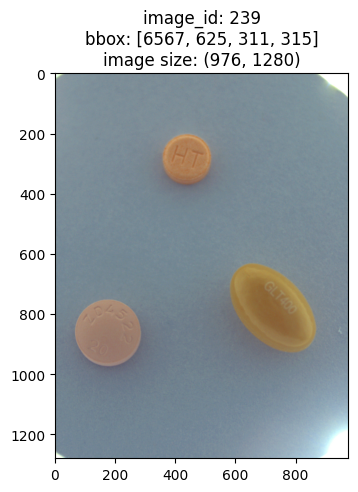

In [ ]:
#이상 BBox 시각화
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

for item in invalid_bboxes:

    image_path = os.path.join(image_dir, item["file_name"])

    image = Image.open(image_path)

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.imshow(image)

    x, y, w, h = item["bbox"]

    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        fill=False
    )

    ax.add_patch(rect)

    ax.set_title(
        f"image_id: {item['image_id']}\n"
        f"bbox: {item['bbox']}\n"
        f"image size: {item['image_size']}"
    )

    plt.show()

2.2 Annotation 누락 의심 데이터

Annotation이 2개인 이미지: 7
알약 3개 / Annotation 2개: 7
알약 4개 / Annotation 3개: 1


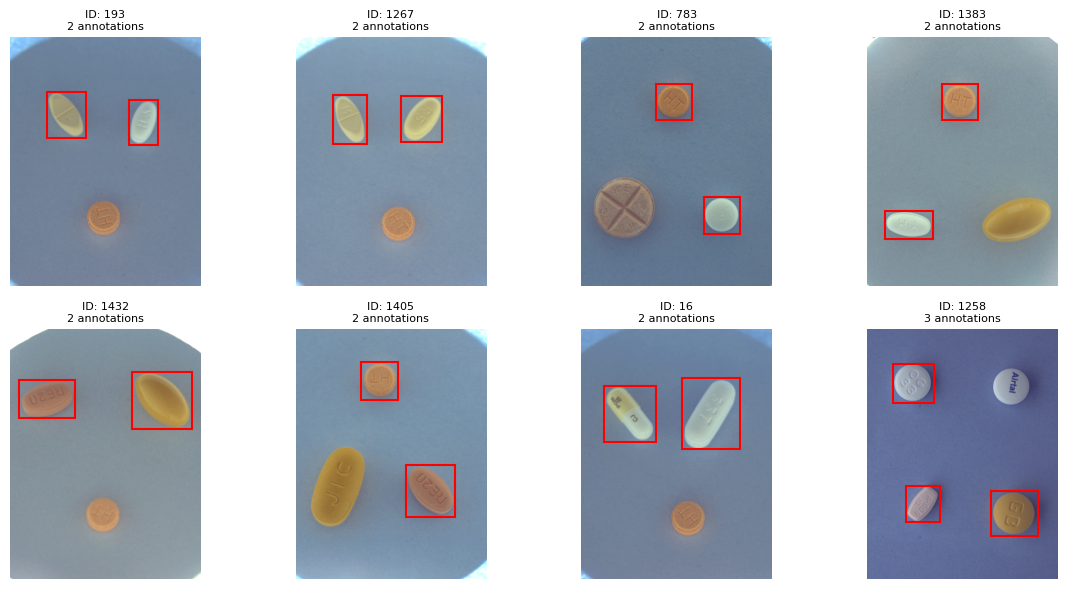

In [30]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


# ========================================
# 1. Annotation 개수가 2개인 이미지 확인
# ========================================

two_ann_images = []

for image_id, item in image_data.items():

    if len(item["annotations"]) == 2:
        two_ann_images.append({
            "image_id": image_id,
            "file_name": item["file_name"],
            "annotations": item["annotations"]
        })

print("Annotation이 2개인 이미지:", len(two_ann_images))


# ========================================
# 2. 파일명 기준 알약 3개 / Annotation 2개
# ========================================

three_pills_two_ann = []

# 알약 4개 / Annotation 3개
four_pills_three_ann = []

for image_id, item in image_data.items():

    file_name = item["file_name"]

    # "_" 앞부분에서 알약 ID 추출
    pill_part = file_name.split("_")[0]
    parts = pill_part.split("-")

    # K를 제외한 숫자 개수 = 실제 알약 개수
    pill_count = len(parts) - 1
    annotation_count = len(item["annotations"])

    if pill_count == 3 and annotation_count == 2:

        three_pills_two_ann.append({
            "image_id": image_id,
            "file_name": file_name,
            "annotations": item["annotations"]
        })

    elif pill_count == 4 and annotation_count == 3:

        four_pills_three_ann.append({
            "image_id": image_id,
            "file_name": file_name,
            "annotations": item["annotations"]
        })


print("알약 3개 / Annotation 2개:", len(three_pills_two_ann))
print("알약 4개 / Annotation 3개:", len(four_pills_three_ann))


# ========================================
# 3. Annotation 누락 의심 데이터 시각화
# ========================================

missing_annotation_images = (
    three_pills_two_ann +
    four_pills_three_ann
)

# 한 줄에 4장
cols = 4

for start in range(0, len(missing_annotation_images), 12):

    page_items = missing_annotation_images[start:start + 12]

    rows = (len(page_items) + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, 3 * rows)
    )

    # 이미지가 1줄인 경우에도 배열 형태 유지
    axes = [axes] if rows == 1 else axes
    axes = list(axes.flat) if hasattr(axes, "flat") else axes

    for ax, item in zip(axes, page_items):

        image_path = os.path.join(
            image_dir,
            item["file_name"]
        )

        image = Image.open(image_path)

        ax.imshow(image)

        # Annotation BBox 표시
        for ann in item["annotations"]:

            x, y, w, h = ann["bbox"]

            rect = patches.Rectangle(
                (x, y),
                w,
                h,
                linewidth=1.5,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)

        ax.set_title(
            f"ID: {item['image_id']}\n"
            f"{len(item['annotations'])} annotations",
            fontsize=8
        )

        ax.axis("off")

    # 남는 subplot 제거
    for ax in axes[len(page_items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

2.3 BBox 중복 여부 확인 (IoU)

IoU 0.5 이상 Annotation 쌍: 3

------------------------------
Image ID: 1228
File: K-001900-016548-019607-033009_0_2_0_2_70_000_200.png
Annotation: 4683 <-> 4691
Category: 16548 <-> 33009
BBox: [88, 255, 366, 209] <-> [88, 255, 366, 209]
IoU: 1.0

------------------------------
Image ID: 907
File: K-003351-020238-031863_0_2_0_2_70_000_200.png
Annotation: 3444 <-> 3441
Category: 3351 <-> 20238
BBox: [446, 844, 190, 191] <-> [446, 844, 190, 191]
IoU: 1.0

------------------------------
Image ID: 208
File: K-003351-029667-031863_0_2_0_2_70_000_200.png
Annotation: 791 <-> 788
Category: 3351 <-> 31863
BBox: [178, 249, 205, 203] <-> [178, 249, 205, 203]
IoU: 1.0


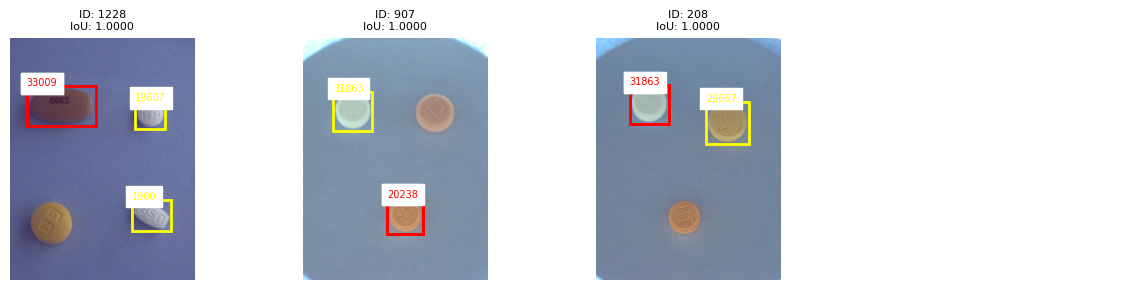

In [33]:
# ============================================================
# IoU 0.5 이상 Annotation 확인
# ============================================================
import numpy as np

def calculate_iou(box1, box2):
    # COCO 형식: [x, y, width, height]
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # 교집합 좌표
    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)

    # 교집합 면적
    inter_w = max(0, xb - xa)
    inter_h = max(0, yb - ya)
    inter_area = inter_w * inter_h

    # 각 BBox 면적
    area1 = w1 * h1
    area2 = w2 * h2

    # 합집합 면적
    union_area = area1 + area2 - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area


# IoU 0.5 이상인 Annotation 쌍 저장
high_iou = []

for image_id, item in image_data.items():

    annotations = item["annotations"]

    # Annotation이 2개 미만이면 비교하지 않음
    if len(annotations) < 2:
        continue

    # Annotation끼리 모든 조합 비교
    for i in range(len(annotations)):
        for j in range(i + 1, len(annotations)):

            ann1 = annotations[i]
            ann2 = annotations[j]

            iou = calculate_iou(
                ann1["bbox"],
                ann2["bbox"]
            )

            if iou >= 0.5:

                high_iou.append({
                    "image_id": image_id,
                    "file_name": item["file_name"],
                    "ann1_id": ann1["id"],
                    "ann2_id": ann2["id"],
                    "category_id1": ann1["category_id"],
                    "category_id2": ann2["category_id"],
                    "bbox1": ann1["bbox"],
                    "bbox2": ann2["bbox"],
                    "iou": iou
                })


# ============================================================
# 결과 출력
# ============================================================

print("IoU 0.5 이상 Annotation 쌍:", len(high_iou))

for result in high_iou:

    print("\n------------------------------")
    print("Image ID:", result["image_id"])
    print("File:", result["file_name"])
    print(
        "Annotation:",
        result["ann1_id"],
        "<->",
        result["ann2_id"]
    )
    print(
        "Category:",
        result["category_id1"],
        "<->",
        result["category_id2"]
    )
    print(
        "BBox:",
        result["bbox1"],
        "<->",
        result["bbox2"]
    )
    print("IoU:", round(result["iou"], 4))


# ============================================================
# IoU 0.5 이상 데이터 시각화
# ============================================================

page_size = 12

for start in range(0, len(high_iou), page_size):

    page_items = high_iou[start:start + page_size]

    cols = 4
    rows = (len(page_items) + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(12, 3 * rows)
    )

    # 1개/여러 개 행 모두 처리
    axes = np.array(axes).reshape(-1)

    for idx, result in enumerate(page_items):

        ax = axes[idx]

        image_path = os.path.join(
            image_dir,
            result["file_name"]
        )

        image = Image.open(image_path)

        ax.imshow(image)

        # 해당 이미지의 모든 Annotation
        annotations = image_data[
            result["image_id"]
        ]["annotations"]

        # IoU가 0.5 이상인 두 Annotation
        overlap_ids = {
            result["ann1_id"],
            result["ann2_id"]
        }

        for ann in annotations:

            x, y, w, h = ann["bbox"]

            # 겹치는 Annotation → 빨간색
            # 나머지 Annotation → 노란색
            if ann["id"] in overlap_ids:
                edge_color = "red"
            else:
                edge_color = "yellow"

            rect = patches.Rectangle(
                (x, y),
                w,
                h,
                linewidth=2,
                edgecolor=edge_color,
                facecolor="none"
            )

            ax.add_patch(rect)

            ax.text(
                x,
                y,
                f'{ann["category_id"]}',
                fontsize=7,
                color=edge_color,
                backgroundcolor="white"
            )

        ax.set_title(
            f'ID: {result["image_id"]}\n'
            f'IoU: {result["iou"]:.4f}',
            fontsize=8
        )

        ax.axis("off")

    # 빈 subplot 제거
    for idx in range(len(page_items), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

2.4 이상 데이터 중복 여부 확인

In [ ]:
# 각각의 검사 결과에서 image_id만 추출

# 1. BBox 범위 오류
invalid_ids = {
    item["image_id"]
    for item in invalid_bboxes
}

# 2. Annotation 누락 의심
missing_ids = {
    item["image_id"]
    for item in three_pills_two_ann
}

missing_ids.update(
    item["image_id"]
    for item in four_pills_three_ann
)

# 3. IoU 겹침
iou_ids = {
    item["image_id"]
    for item in high_iou
}


print("BBox 범위 오류:", invalid_ids)
print("Annotation 누락:", missing_ids)
print("IoU 겹침:", iou_ids)


# 전체 이상 이미지
all_ids = invalid_ids | missing_ids | iou_ids

print("\n전체 이상 이미지 수:", len(all_ids))
print("Image IDs:", sorted(all_ids))

BBox 범위 오류: {239}
Annotation 누락: {193, 1383, 1258, 783, 16, 1267, 1432, 1405}
IoU 겹침: {208, 907, 1228}

전체 이상 이미지 수: 12
Image IDs: [16, 193, 208, 239, 783, 907, 1228, 1258, 1267, 1383, 1405, 1432]


3. 클래스 매핑

In [8]:
# 모든 annotation에서 category_id 수집
category_ids = set()

for item in image_data.values():
    for ann in item["annotations"]:
        category_ids.add(ann["category_id"])

print("총 클래스 수:", len(category_ids))

총 클래스 수: 56


In [9]:
category_to_class = {
    category_id: class_id
    for class_id, category_id in enumerate(sorted(category_ids))
}

print("총 클래스 수:", len(category_to_class))

for category_id, class_id in list(category_to_class.items())[:10]:
    print(
        f"category_id: {category_id} → class_id: {class_id}"
    )

총 클래스 수: 56
category_id: 1900 → class_id: 0
category_id: 2483 → class_id: 1
category_id: 3351 → class_id: 2
category_id: 3483 → class_id: 3
category_id: 3544 → class_id: 4
category_id: 3743 → class_id: 5
category_id: 3832 → class_id: 6
category_id: 4543 → class_id: 7
category_id: 12081 → class_id: 8
category_id: 12247 → class_id: 9


4. BBox 변환함수

In [10]:
def convert_bbox_to_yolo(bbox, image_width, image_height):
    x, y, w, h = bbox

    #중심 좌표 계산
    x_center = x + w / 2
    y_center = y + h / 2

    # 0~1 사이로 정규화
    x_center /= image_width
    y_center /= image_height
    w /= image_width
    h /= image_height

    return x_center, y_center, w, h

In [11]:
# 첫 번째 이미지 가져오기
image_id, item = next(iter(image_data.items()))

# 첫 번째 annotation
ann = item["annotations"][0]

yolo_bbox = convert_bbox_to_yolo(
    ann["bbox"],
    item["width"],
    item["height"]
)

class_id = category_to_class[ann["category_id"]]

print("원본 bbox:", ann["bbox"])
print("category_id:", ann["category_id"])
print("class_id:", class_id)
print("YOLO bbox:", yolo_bbox)

원본 bbox: [644, 845, 189, 190]
category_id: 1900
class_id: 0
YOLO bbox: (0.7566598360655737, 0.734375, 0.19364754098360656, 0.1484375)


5. YOLO 라벨 변환

In [36]:
# 학습에서 제외할 이미지
exclude_image_ids = {
    16, 193, 208, 239, 783, 907,
    1228, 1258, 1267, 1383, 1405, 1432
}

yolo_labels = {}

for image_id, item in image_data.items():

    # 이상 데이터 이미지 전체 제외
    if image_id in exclude_image_ids:
        continue

    labels = []

    image_width = item["width"]
    image_height = item["height"]

    for ann in item["annotations"]:

        # category_id → YOLO class_id
        class_id = category_to_class[ann["category_id"]]

        # YOLO 형식으로 변환
        x_center, y_center, w, h = convert_bbox_to_yolo(
            ann["bbox"],
            image_width,
            image_height
        )

        labels.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} "
            f"{w:.6f} {h:.6f}"
        )

    yolo_labels[image_id] = labels

In [40]:
print("변환된 이미지 수:", len(yolo_labels))
print("변환된 annotation 수:", sum(len(labels) for labels in yolo_labels.values()))

변환된 이미지 수: 220
변환된 annotation 수: 733


In [38]:
for image_id, labels in yolo_labels.items():
    print("image_id:", image_id)
    
    for label in labels:
        print(label)
    
    break

image_id: 34
0 0.756660 0.734375 0.193648 0.148438
15 0.269980 0.717578 0.244877 0.186719
22 0.752561 0.282813 0.158811 0.117188
42 0.311475 0.273438 0.401639 0.206250


6. 클래스별 데이터 분포 및 불균형 분석

,YOLO Class ID,Category ID,Annotation Count
0,0,3351,147
1,1,3483,45
2,2,35206,36
3,3,16262,22
4,4,16232,21
5,5,21325,20
6,6,3832,20
7,7,20238,19
8,8,36637,18
9,9,19232,17


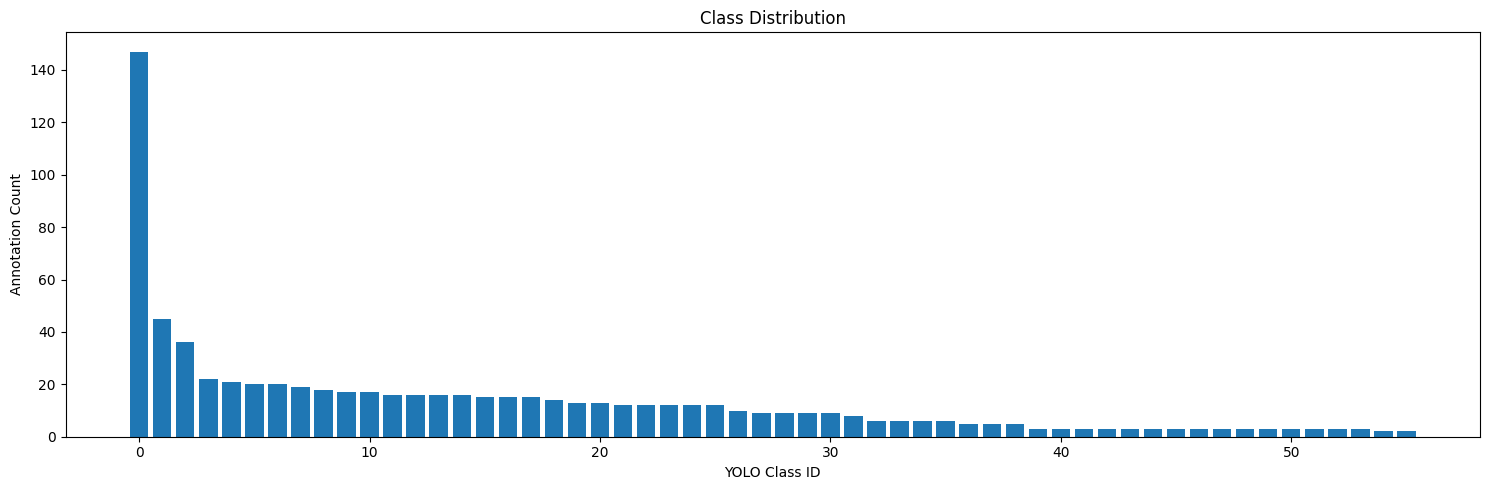

클래스 수: 56
최대 클래스: 147개
최소 클래스: 2개
최대/최소 비율: 73.5배


In [10]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ANNOTATION_DIR = Path("../data/raw/sprint_ai_project1_data/train_annotations")

EXCLUDE_IMAGE_IDS = {
    16, 193, 208, 239, 783, 907,
    1228, 1258, 1267, 1383, 1405, 1432
}

class_counts = {}

# JSON 전체 탐색
for json_file in ANNOTATION_DIR.rglob("*.json"):
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    # COCO 형식
    image_id = data["images"][0]["id"]

    if image_id in EXCLUDE_IMAGE_IDS:
        continue

    for ann in data["annotations"]:
        bbox = ann["bbox"]

        # 잘못된 bbox 제외
        if len(bbox) != 4 or bbox[2] <= 0 or bbox[3] <= 0:
            continue

        category_id = ann["category_id"]
        class_counts[category_id] = class_counts.get(category_id, 0) + 1


# 표
df = pd.DataFrame(
    class_counts.items(),
    columns=["Category ID", "Annotation Count"]
)

df = df.sort_values("Annotation Count", ascending=False).reset_index(drop=True)

df["YOLO Class ID"] = range(len(df))

df = df[["YOLO Class ID", "Category ID", "Annotation Count"]]

display(df)


# 그래프
plt.figure(figsize=(15, 5))
plt.bar(df["YOLO Class ID"], df["Annotation Count"])

plt.xlabel("YOLO Class ID")
plt.ylabel("Annotation Count")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()


# 불균형 정도
print(f"클래스 수: {len(df)}")
print(f"최대 클래스: {df['Annotation Count'].max()}개")
print(f"최소 클래스: {df['Annotation Count'].min()}개")
print(f"최대/최소 비율: {df['Annotation Count'].max() / df['Annotation Count'].min():.1f}배")